# CARDIOVISION 3D — STEP 4: EXPLAINABLE AI (SHAP) FOR CAD, LAD, LCX & RCA

## Executive Overview
This notebook implements **Step 4: Explainable AI (SHAP)** of the CardioVision 3D pipeline.
The goal is to construct a transparent, robust SHAP-based explainability layer for all four targets:
1. **CAD** (Coronary Artery Disease)
2. **LAD** (Left Anterior Descending)
3. **LCX** (Left Circumflex)
4. **RCA** (Right Coronary Artery)

Using the actual final models selected and saved in **Step 3** (`ml/artifacts/final/`), we calculate global feature importances, local individual patient explanations, feature interaction plots, and structured JSON outputs for API integration.

### Core Safety Principle:
> *"Explain what the model learned and how features contributed to its output, without turning model associations into clinical causal claims."*


## 1. Inspect Final Models & Metadata
Before initializing SHAP explainers, we read `ml/artifacts/final/model_metadata.json` to inspect model types, calibration status, thresholds, and input feature counts.


In [1]:
import sys, os, json

# Dynamically locate project root containing 'ml' and 'data' folders
curr = os.path.abspath(".")
root = curr
while root and not (os.path.exists(os.path.join(root, "ml")) and os.path.exists(os.path.join(root, "data"))):
    parent = os.path.dirname(root)
    if parent == root:
        break
    root = parent

if root and root not in sys.path:
    sys.path.insert(0, root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from ml.src.preprocessing import clean_dataset, map_targets, get_feature_lists
from ml.src.explainability import (
    resolve_path,
    load_final_models,
    extract_pipeline_and_classifier,
    compute_global_shap,
    explain_patient
)

# Load metadata and models
models, metadata = load_final_models("ml/artifacts/final")

meta_summary = []
for t in ["cad", "lad", "lcx", "rca"]:
    info = metadata[t]
    preprocessor, clf, calib_status, is_calib = extract_pipeline_and_classifier(models[t])
    meta_summary.append({
        "Target": info["target"],
        "Model": info["model"],
        "Calibration": info["calibration"],
        "Selected Threshold": info["selected_threshold"],
        "Input Feature Count": info["features_count"],
        "Classifier Class": type(clf).__name__
    })

pd.DataFrame(meta_summary)


,Target,Model,Calibration,Selected Threshold,Input Feature Count,Classifier Class
0,CAD,Logistic Regression (Default),Uncalibrated,0.50,54,LogisticRegression
1,LAD,Random Forest (Balanced),Sigmoid,0.50,54,RandomForestClassifier
2,LCX,SVM (Balanced),Sigmoid,0.45,54,SVC
3,RCA,Logistic Regression (Balanced),Uncalibrated,0.45,54,LogisticRegression


## 2. Global SHAP Feature Importance Calculation
We calculate global feature importances for CAD, LAD, LCX, and RCA by mapping preprocessed One-Hot Encoded and scaled columns back to the 54 original raw input features.


In [2]:
# Load dataset
df_raw = pd.read_excel(resolve_path("data/extention of Z-Alizadeh sani dataset.xlsx"))
df_clean = clean_dataset(df_raw)
df_mapped = map_targets(df_clean)

with open(resolve_path("ml/reports/feature_types.json"), "r") as f:
    feature_types = json.load(f)

num_cols, cat_cols, bin_cols = get_feature_lists(df_mapped, feature_types)
raw_features = num_cols + cat_cols + bin_cols
X_raw = df_mapped[raw_features]

global_dfs = {}
global_infos = {}
raw_shap_dfs = {}

for target in ["cad", "lad", "lcx", "rca"]:
    print(f"Calculating SHAP for {target.upper()}...")
    shap_df_raw, mean_abs_df, info = compute_global_shap(
        models[target], target, X_raw, raw_features, n_kmeans_bg=10, random_state=42
    )
    raw_shap_dfs[target] = shap_df_raw
    global_dfs[target] = mean_abs_df
    global_infos[target] = info

print("Global SHAP computation complete for all targets!")


Background dataset has 303 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=303 when initializing the masker.


Calculating SHAP for CAD...
Calculating SHAP for LAD...


Calculating SHAP for LCX...


  0%|          | 0/101 [00:00<?, ?it/s]

Background dataset has 303 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=303 when initializing the masker.


Calculating SHAP for RCA...
Global SHAP computation complete for all targets!


### Top 10 Global Features by Target

In [3]:
top10_df = pd.DataFrame({
    "CAD Top Features": global_dfs["cad"].head(10)["feature"].values,
    "CAD |SHAP|": global_dfs["cad"].head(10)["mean_abs_shap"].round(4).values,
    "LAD Top Features": global_dfs["lad"].head(10)["feature"].values,
    "LAD |SHAP|": global_dfs["lad"].head(10)["mean_abs_shap"].round(4).values,
    "LCX Top Features": global_dfs["lcx"].head(10)["feature"].values,
    "LCX |SHAP|": global_dfs["lcx"].head(10)["mean_abs_shap"].round(4).values,
    "RCA Top Features": global_dfs["rca"].head(10)["feature"].values,
    "RCA |SHAP|": global_dfs["rca"].head(10)["mean_abs_shap"].round(4).values,
})
top10_df


,CAD Top Features,CAD |SHAP|,LAD Top Features,LAD |SHAP|,LCX Top Features,LCX |SHAP|,RCA Top Features,RCA |SHAP|
0,Typical Chest Pain,1.1073,Atypical,0.0641,Age,0.0663,DM,0.6157
1,Age,0.7698,Typical Chest Pain,0.0603,PLT,0.0185,Sex,0.5860
2,Dyspnea,0.5648,EF-TTE,0.0466,Na,0.0169,Age,0.5802
3,Region RWMA,0.5559,Region RWMA,0.0427,LDL,0.0157,Dyspnea,0.4233
4,Tinversion,0.5172,Age,0.0334,Typical Chest Pain,0.0147,Weight,0.4192
5,TG,0.4978,ESR,0.0259,FBS,0.0129,ESR,0.3931
6,EF-TTE,0.4950,Sex,0.0159,EF-TTE,0.0091,Function Class,0.3482
7,DM,0.4780,PR,0.0157,BP,0.0077,Typical Chest Pain,0.3294
8,HTN,0.4330,HTN,0.0147,TG,0.0076,BUN,0.3222
9,BMI,0.4306,Lymph,0.0145,Neut,0.0074,Neut,0.3117


## 3. Global SHAP Visualizations
Plotting feature importance bar charts and summary/beeswarm plots for each vessel.


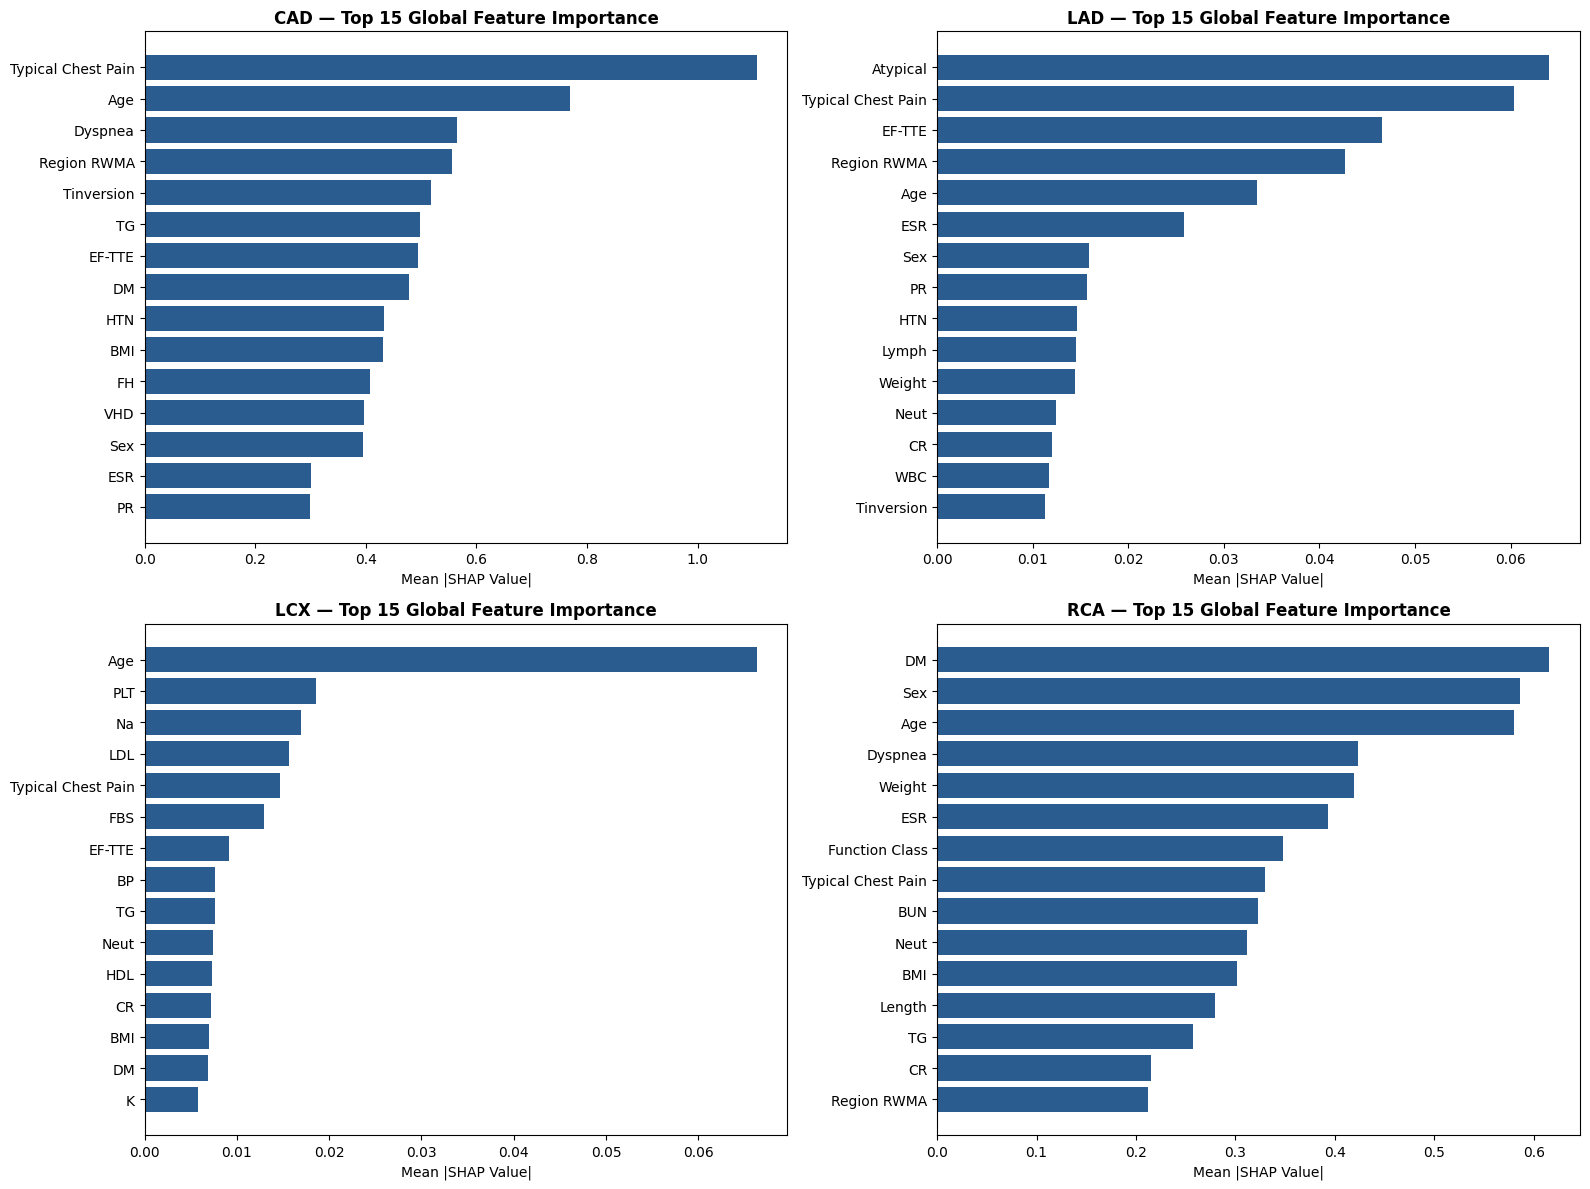

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
targets = ["cad", "lad", "lcx", "rca"]

for idx, t in enumerate(targets):
    ax = axes[idx // 2, idx % 2]
    top15 = global_dfs[t].head(15).sort_values(by="mean_abs_shap", ascending=True)
    ax.barh(top15["feature"], top15["mean_abs_shap"], color="#2b5c8f")
    ax.set_title(f"{t.upper()} — Top 15 Global Feature Importance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean |SHAP Value|")

plt.tight_layout()
plt.show()


## 4. Local Patient Explanation (Individual Prediction)
Demonstrating patient-level feature decomposition and deterministic natural-language explanation.


In [5]:
patient_idx = 0
patient_row = X_raw.iloc[[patient_idx]]

cad_local = explain_patient("cad", models["cad"], patient_row, X_raw, raw_features, metadata)

print(f"=== LOCAL EXPLANATION FOR CAD (Patient #{patient_idx}) ===")
print(f"Probability Output: {cad_local['probability']:.4f} (Threshold: {cad_local['threshold']})")
print(f"Predicted Class: {cad_local['predicted_class']}")
print(f"Base Value: {cad_local['shap_base_value']}")
print(f"Sum of SHAP Contributions: {cad_local['shap_sum_contributions']}")
print("\nTop 5 Contributing Features:")
for feat_item in cad_local["top_features"][:5]:
    print(f" - {feat_item['natural_language_summary']}")


Background dataset has 303 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=303 when initializing the masker.


=== LOCAL EXPLANATION FOR CAD (Patient #0) ===
Probability Output: 0.8648 (Threshold: 0.5)
Predicted Class: 1
Base Value: 2.3661
Sum of SHAP Contributions: -0.5102

Top 5 Contributing Features:
 - 'Typical Chest Pain' (patient value: 0) contributed negatively to the model's CAD probability output.
 - 'TG' (patient value: 250) contributed positively to the model's CAD probability output.
 - 'Tinversion' (patient value: 1) contributed positively to the model's CAD probability output.
 - 'Dyspnea' (patient value: N) contributed positively to the model's CAD probability output.
 - 'VHD' (patient value: N) contributed positively to the model's CAD probability output.


## 5. Explanation Quality & Mathematical Consistency Verification
Validating base value + sum(SHAP) consistency and documenting calibration handling.


In [6]:
quality_df = pd.read_csv(resolve_path("ml/reports/explanation_quality_report.csv"))
quality_df


,target,model,explainer,number_of_features,top_features,explanation_consistency_check,notes
0,CAD,Logistic Regression (Default),LinearExplainer,54,"Typical Chest Pain, Age, Dyspnea, Region RWMA,...",PASSED (Base value + Sum(SHAP) matches model d...,Calibrated status: Uncalibrated. SHAP aggregat...
1,LAD,Random Forest (Balanced),TreeExplainer,54,"Atypical, Typical Chest Pain, EF-TTE, Region R...",PASSED (Base value + Sum(SHAP) matches model d...,Calibrated status: Sigmoid. SHAP aggregated fr...
2,LCX,SVM (Balanced),KernelExplainer,54,"Age, PLT, Na, LDL, Typical Chest Pain",PASSED (Base value + Sum(SHAP) matches model d...,Calibrated status: Sigmoid. SHAP aggregated fr...
3,RCA,Logistic Regression (Balanced),LinearExplainer,54,"DM, Sex, Age, Dyspnea, Weight",PASSED (Base value + Sum(SHAP) matches model d...,Calibrated status: Uncalibrated. SHAP aggregat...
